<a href="https://colab.research.google.com/github/hassan1662n/Deep-learning-projects/blob/main/CIFAR_10_Object_Recognition_using_ResNet50.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle
!chmod 600 ~/.kaggle/kaggle.json

In [2]:
!kaggle competitions download -c cifar-10

100% 715M/715M [00:04<00:00, 159MB/s]



In [3]:
!ls

cifar-10.zip  kaggle.json  sample_data


In [4]:
from zipfile import ZipFile
datasets = '/content/cifar-10.zip'

with ZipFile(datasets, 'r') as zip:
  zip.extractall()
  print('Done')

Done


In [5]:
!ls

cifar-10.zip  sample_data	    test.7z   trainLabels.csv
kaggle.json   sampleSubmission.csv  train.7z


In [6]:
!pip install py7zr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.2/72.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 496.2/496.2 kB 20.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100.6/100.6 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.3/52.3 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 18.1 MB/s eta 0:00:00


In [7]:
import py7zr
archive = py7zr.SevenZipFile("/content/train.7z", mode="r")
archive.extractall()
archive.close()

In [8]:
import numpy as np
import os
import matplotlib.pyplot as plt
import pandas as pd
from PIL import Image
import matplotlib.image as mpimg
from sklearn.model_selection import train_test_split

In [9]:
filename = os.listdir('/content/train')

In [10]:
len(filename)

50000

In [11]:
print(filename[0:5])

['42983.png', '21479.png', '17163.png', '21498.png', '17677.png']


In [12]:
labels_df = pd.read_csv('/content/trainLabels.csv')

In [13]:
labels_df.shape

(50000, 2)

In [14]:
labels_df.head()

,id,label
0,1,frog
1,2,truck
2,3,truck
3,4,deer
4,5,automobile


In [15]:
labels_df['label'].value_counts()

,count
label,
frog,5000
truck,5000
deer,5000
automobile,5000
bird,5000
horse,5000
ship,5000
cat,5000
dog,5000


In [18]:
label_dic = {'airplane':0, 'automobile':1, 'bird':2, 'cat':3, 'deer':4, 'dog':5, 'frog':6, 'horse':7, 'ship':8, 'truck':9}

labels = [label_dic[i] for i in labels_df['label']]

In [19]:
print(labels[0:5])

[6, 9, 9, 4, 1]


In [20]:
id_list = list(labels_df['id'])

In [21]:
train_data_folder = '/content/train/'
data = []
for id in id_list:
  image = Image.open(train_data_folder + str(id) + '.png')
  image = np.array(image)
  data.append(image)

In [22]:
type(data)

list

In [23]:
len(data)

50000

In [24]:
data[0].shape

(32, 32, 3)

In [25]:
X = np.array(data)
Y = np.array(labels)

In [26]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape)
print(X_test.shape)
print(Y_train.shape)
print(Y_test.shape)

(40000, 32, 32, 3)
(10000, 32, 32, 3)
(40000,)
(10000,)


In [27]:
X_train_scaled = X_train/255
X_test_scaled = X_test/255

In [28]:
X_train_scaled

array([[[[0.13333333, 0.14117647, 0.16862745],
         [0.14509804, 0.14509804, 0.2       ],
         [0.17254902, 0.17254902, 0.25098039],
         ...,
         [0.24313725, 0.28627451, 0.36470588],
         [0.20392157, 0.24705882, 0.3254902 ],
         [0.17647059, 0.22352941, 0.30196078]],

        [[0.1372549 , 0.1372549 , 0.14509804],
         [0.13333333, 0.13333333, 0.15686275],
         [0.13333333, 0.12941176, 0.16862745],
         ...,
         [0.22745098, 0.27058824, 0.34901961],
         [0.19607843, 0.23529412, 0.31372549],
         [0.18431373, 0.22745098, 0.30588235]],

        [[0.13333333, 0.12941176, 0.1372549 ],
         [0.12941176, 0.1254902 , 0.14117647],
         [0.12941176, 0.1254902 , 0.14901961],
         ...,
         [0.25882353, 0.30196078, 0.38039216],
         [0.2       , 0.24313725, 0.32156863],
         [0.20784314, 0.25098039, 0.32941176]],

        ...,

        [[0.1254902 , 0.1254902 , 0.14901961],
         [0.1254902 , 0.12156863, 0.14509804]

In [29]:
import tensorflow as tf
from tensorflow import keras

In [30]:
num_of_classes = 10

# setting up the layers of Neural Network

model = keras.Sequential([

    keras.layers.Flatten(input_shape=(32,32,3)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(num_of_classes, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [31]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [32]:
model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.2788 - loss: 1.9789 - val_accuracy: 0.3013 - val_loss: 1.9071
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 9s 3ms/step - accuracy: 0.3301 - loss: 1.8530 - val_accuracy: 0.3368 - val_loss: 1.8333
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.3496 - loss: 1.8025 - val_accuracy: 0.3480 - val_loss: 1.8028
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3625 - loss: 1.7818 - val_accuracy: 0.3512 - val_loss: 1.7833
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3700 - loss: 1.7580 - val_accuracy: 0.3562 - val_loss: 1.7751
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.3757 - loss: 1.7450 - val_accuracy: 0.3358 - val_loss: 1.8253
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3810 - loss: 1.7325 - val_accuracy: 0.3685 - val_loss: 1.7591
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.3806 - loss: 1.7273 - 

Pretrained model with ResNet50

In [33]:
from tensorflow.keras import Sequential,layers, models
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.models import load_model
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras import optimizers

In [34]:
convo_base = ResNet50(weights='imagenet', include_top=False, input_shape=(256,256,3))
convo_base.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "resnet50"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 23,587,712 (89.98 MB)

 Trainable params: 23,534,592 (89.78 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [35]:
num_of_classes = 10

model = models.Sequential()
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(layers.UpSampling2D((2,2)))
model.add(convo_base)
model.add(layers.Flatten())
model.add(layers.BatchNormalization())
model.add(layers.Dense(128, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(64, activation='relu'))
model.add(layers.Dropout(0.5))
model.add(layers.BatchNormalization())
model.add(layers.Dense(num_of_classes, activation='softmax'))

In [37]:
model.compile(optimizer=optimizers.RMSprop(learning_rate=0.01), loss='sparse_categorical_crossentropy', metrics=['acc'])

In [38]:
history = model.fit(X_train_scaled, Y_train, validation_split=0.1, epochs=10)

Epoch 1/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 461s 362ms/step - acc: 0.1952 - loss: 2.1305 - val_acc: 0.2013 - val_loss: 2.1316
Epoch 2/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 417s 371ms/step - acc: 0.3321 - loss: 1.7776 - val_acc: 0.4215 - val_loss: 1.5768
Epoch 3/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 419s 373ms/step - acc: 0.4325 - loss: 1.5592 - val_acc: 0.5145 - val_loss: 1.3609
Epoch 4/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 420s 374ms/step - acc: 0.5073 - loss: 1.3941 - val_acc: 0.4585 - val_loss: 1.7448
Epoch 5/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 421s 374ms/step - acc: 0.5548 - loss: 1.2814 - val_acc: 0.6055 - val_loss: 1.0929
Epoch 6/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 421s 374ms/step - acc: 0.5886 - loss: 1.1974 - val_acc: 0.5997 - val_loss: 1.1378
Epoch 7/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 422s 375ms/step - acc: 0.6205 - loss: 1.1122 - val_acc: 0.6702 - val_loss: 0.9393
Epoch 8/10
1125/1125 ━━━━━━━━━━━━━━━━━━━━ 422s 375ms/step - acc: 0.6491 - loss: 1.0448 - val_acc: 0.6600 - val_loss: 0.9771
Epoch 9/

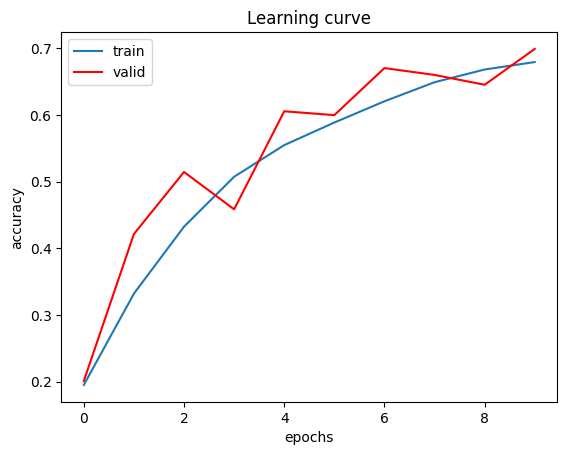

In [42]:
h = history

plt.plot(h.history['acc'])
plt.plot(h.history['val_acc'], c = 'red')
plt.title('Learning curve')
plt.ylabel('accuracy')
plt.xlabel('epochs')
plt.legend(['train', 'valid'])

In [43]:
loss, accuracy = model.evaluate(X_test_scaled, Y_test)
print('Test Accuracy =', accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 40s 112ms/step - acc: 0.6945 - loss: 0.8716
Test Accuracy = 0.6945000290870667


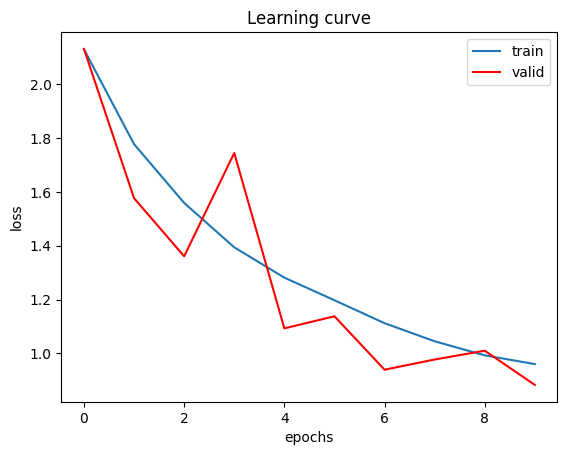

In [44]:
plt.plot(h.history['loss'])
plt.plot(h.history['val_loss'], c = 'red')
plt.title('Learning curve')
plt.ylabel('loss')
plt.xlabel('epochs')
plt.legend(['train', 'valid'])